# VLM → Dubins Failure Margin

End-to-end pipeline: use a **VLM** to label preferences over rendered Dubins states, learn a
**Bradley-Terry failure margin** on the frozen world-model latent, **calibrate** its zero, and
evaluate it — including the safe-set error that the downstream HJ reach-avoid filter depends on.

**Run from the repo root** with the **`vlm_qwen3`** kernel (`conda activate vlm_qwen3` — it carries
both the DreamerV3 world-model stack and Qwen3-VL). Artifacts live in `vlm_labeling/`.

**Pipeline**
1. World model → 544-d latent for each state
2. **VLM labeling** — stepwise pairwise prompt (VLM sees both images and decides)
3. **BT margin** on the latent
4. **Calibration** — fit the arbitrary BT zero from ~50 clean sign anchors
5. **Evaluation** — label accuracy, held-out margin accuracy, calibrated safe-set error
6. Results & diagnostics

**Headline numbers** (set_a, Qwen3-VL-4B-Instruct @256px): stepwise labels **0.746** vs GT
(direct pairwise baseline 0.697); VLM-only margin reaches **0.80** held-out accuracy and **25%**
calibrated safe-set error; clean labels remain far stronger (1000 clean → 0.986 / 5%).

## 0. Setup

In [1]:
import os, sys, re, pickle, argparse
os.environ.setdefault("CUDA_VISIBLE_DEVICES","1"); os.environ.setdefault("HF_HUB_OFFLINE","1")
sys.path.insert(0, os.getcwd()); sys.path.insert(0, "eais_hw2/dreamerv3-torch")
import numpy as np, torch, torch.nn as nn, gym
from torch.nn.utils import spectral_norm
import ruamel.yaml as yaml, tools, models
import matplotlib.pyplot as plt
from PIL import Image
import generate_data_dubins_sidewalk as gen
from generate_pref_labels_dubins_sidewalk import weighted_margin_np, PREF_PROFILES
V="vlm_labeling"; dev=torch.device("cuda")

D=pickle.load(open("data/pref_labels_set_a_50k.pkl","rb"))
imgs=D["imgs"]; margin=D["margin"].astype(np.float32); priv=D["priv"]; Mn=len(margin)
R,SW=float(D["R"]),float(D["SW"]); W=PREF_PROFILES["set_a"]
cfg=yaml.YAML(typ="safe",pure=True).load(open("eais_hw2/configs.yaml").read())["defaults"]
config=argparse.Namespace(**{k:tools.args_type(v)(v) for k,v in cfg.items()})
config.num_actions=3; config.device=dev; config.use_margin_head=False

def is_obs(k): return np.hypot(priv[k,0],priv[k,1])<R
def is_sw(k):  return abs(priv[k,1])>SW and not is_obs(k)
def region(k):
    if is_obs(k): return "OBSTACLE"
    if priv[k,1]>SW:  return "UPPER_SIDEWALK"
    if priv[k,1]<-SW: return "LOWER_SIDEWALK"
    return "UPPER_SAFE" if priv[k,1]>=0 else "LOWER_SAFE"
# fixed split: labels come from the train pool, evaluation from the held-out val pool
rng=np.random.default_rng(0); vmask=np.zeros(Mn,bool); vmask[rng.choice(Mn,int(0.2*Mn),replace=False)]=True
train_idx=np.where(~vmask)[0]; val_idx=np.where(vmask)[0]
print(f"{Mn} states | R={R} SW={SW} | train {len(train_idx)} / val {len(val_idx)}")

4000 states | R=0.5 SW=1.1 | train 3200 / val 800


## 1. World model → latents
The margin lives on the frozen transition-only WM latent (544-d), because that is the space the downstream latent safety filter operates in. Cached.

In [2]:
sz=config.size[0]
obs_space=gym.spaces.Dict({"obs_state":gym.spaces.Box(-1,1,(2,),np.float32),
                           "image":gym.spaces.Box(0,255,(sz,sz,3),np.uint8)})
wm=models.WorldModel(obs_space,gym.spaces.Discrete(3),0,config).to(dev)
_ck=torch.load("checkpoints/wm_transition_only.pt",map_location=dev)
_sd={k[len("_wm._orig_mod."):] if k.startswith("_wm._orig_mod.") else k[4:] if k.startswith("_wm.") else k:v
     for k,v in _ck["agent_state_dict"].items() if "_wm" in k}
wm.load_state_dict(_sd,strict=True); wm.eval(); wm.dynamics.sample=False

@torch.no_grad()
def encode(im_arr, ob_arr, chunk=256):
    out=[]
    for k in range(0,len(im_arr),chunk):
        im=im_arr[k:k+chunk].astype(np.float32); ob=ob_arr[k:k+chunk].astype(np.float32); B=len(im)
        acs=np.zeros((B,1,3),np.float32); acs[:,:,1]=1.0
        d={"image":im[:,None],"obs_state":ob[:,None],"action":acs,
           "is_first":np.ones((B,1),np.float32),"is_terminal":np.zeros((B,1),np.float32)}
        d=wm.preprocess(d); e=wm.encoder(d); post,_=wm.dynamics.observe(e,d["action"],d["is_first"])
        out.append(wm.dynamics.get_feat(post)[:,0])
    return torch.cat(out,0)

_fc=f"{V}/pool_feats.pt"
feats=torch.load(_fc,map_location=dev) if os.path.exists(_fc) else encode(D["imgs"],D["obs_state"])
if not os.path.exists(_fc): torch.save(feats,_fc)
print("latents:",tuple(feats.shape))

Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}


Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}


Optimizer model_opt has 27134213 variables.
latents: (4000, 544)


/home/alina/projects/latent_pref_reachability/eais_hw2/dreamerv3-torch/tools.py:891: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


## 2. VLM labeling — stepwise pairwise prompt

The VLM sees **both images in one call** and makes the comparison itself. We supply the region
**rules** and the preference **ranking**, but do no arithmetic: the model writes out
locate A → classify A → locate B → classify B → compare → answer.

Two findings drove this design:
* **Worked step-by-step demos are decisive** — zero-shot with identical rules scores **0.587**, with
  4 worked demos **0.807** (on a 300-pair slice).
* Framing that works for *single-image* perception does **not** transfer to two-image comparison; the
  VLM is much stronger at perceiving one image than at comparing two.

In [3]:
SCENE=("You will see two pictures from the same top-down map: State A first, then State B. In each "
 "picture: most of the map is plain WHITE background; a GRAY horizontal band runs along the very TOP "
 "edge; another GRAY band runs along the very BOTTOM edge; a RED circle with a green tree sits in the "
 "middle; and there is one small BLUE CAR. Coordinates: x goes from -1.5 (left) to +1.5 (right), y goes "
 "from -1.5 (bottom) to +1.5 (top). The top gray band is y > 1.1, the bottom gray band is y < -1.1, and "
 "the red circle is everything within distance 0.5 of the centre (0,0).")
RULES=("\n\nRegion rules for a car:\n"
 " - if the car is on the RED circle (within distance 0.5 of the centre) -> OBSTACLE\n"
 " - else if the car is on the TOP gray band (y > 1.1) -> UPPER_SIDEWALK\n"
 " - else if the car is on the BOTTOM gray band (y < -1.1) -> LOWER_SIDEWALK\n"
 " - else if the car is on the white background with y >= 0 -> UPPER_SAFE\n"
 " - else (white background, y < 0) -> LOWER_SAFE\n"
 "The tree may cover the car; if the car is on the red circle it is OBSTACLE.")
RANK=("\n\nPreference ranking, safest first:\n"
 " UPPER_SAFE  >  LOWER_SAFE  >  UPPER_SIDEWALK  =  LOWER_SIDEWALK  >  OBSTACLE")
STEPS=("\n\nNow work through these steps and write each one out:\n"
 "Step 1. Car A: say where the blue car is in State A (what it is sitting on, and roughly its y value).\n"
 "Step 2. Region A: give State A's region using the region rules.\n"
 "Step 3. Car B: say where the blue car is in State B (what it is sitting on, and roughly its y value).\n"
 "Step 4. Region B: give State B's region using the region rules.\n"
 "Step 5. Compare Region A and Region B using the preference ranking, and say which one ranks higher.\n"
 'Finally end with a line exactly "Answer: A" or "Answer: B" naming the safer state.')
print(SCENE+RULES+RANK+STEPS)

You will see two pictures from the same top-down map: State A first, then State B. In each picture: most of the map is plain WHITE background; a GRAY horizontal band runs along the very TOP edge; another GRAY band runs along the very BOTTOM edge; a RED circle with a green tree sits in the middle; and there is one small BLUE CAR. Coordinates: x goes from -1.5 (left) to +1.5 (right), y goes from -1.5 (bottom) to +1.5 (top). The top gray band is y > 1.1, the bottom gray band is y < -1.1, and the red circle is everything within distance 0.5 of the centre (0,0).

Region rules for a car:
 - if the car is on the RED circle (within distance 0.5 of the centre) -> OBSTACLE
 - else if the car is on the TOP gray band (y > 1.1) -> UPPER_SIDEWALK
 - else if the car is on the BOTTOM gray band (y < -1.1) -> LOWER_SIDEWALK
 - else if the car is on the white background with y >= 0 -> UPPER_SAFE
 - else (white background, y < 0) -> LOWER_SAFE
The tree may cover the car; if the car is on the red circle it

### The labeler (live demo on a few pairs)
Bulk generation is `vlm_labeling/gen_stepwise_batched.py` (batched: 0.76 s/pair vs 3.2 s sequential). Here we load the model and label a handful of pairs to show it end to end.

In [4]:
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
from qwen_vl_utils import process_vision_info
_M="Qwen/Qwen3-VL-4B-Instruct"; DPI=256
proc=AutoProcessor.from_pretrained(_M)
vlm=Qwen3VLForConditionalGeneration.from_pretrained(_M,dtype=torch.bfloat16).to("cuda").eval()
def render(k): return Image.fromarray(gen.render_state(priv[k].astype(np.float32),1.0,0.05,
                                                       gen.load_tree_emoji(),DPI).astype(np.uint8))
@torch.no_grad()
def ask(content,mx=230):
    m=[{"role":"user","content":content}]
    t=proc.apply_chat_template(m,tokenize=False,add_generation_prompt=True)
    vi,vv=process_vision_info(m); inp=proc(text=[t],images=vi,videos=vv,return_tensors="pt").to("cuda")
    n=int(inp["input_ids"].shape[1]); o=vlm.generate(**inp,max_new_tokens=mx,do_sample=False)
    return proc.tokenizer.decode(o[0][n:],skip_special_tokens=True)
def parse_ab(t):
    m=re.findall(r"[Aa]nswer\s*[:\-]?\s*\(?([AB])\b",t); return m[-1].upper() if m else None
def sit(k):
    if is_obs(k): return f"sitting on the red circle (y about {priv[k,1]:+.1f})"
    if is_sw(k):  return f"sitting on the {'top' if priv[k,1]>0 else 'bottom'} gray band (y about {priv[k,1]:+.1f})"
    return f"on the white background (y about {priv[k,1]:+.1f})"
def worked(a,b):
    ra,rb=region(a),region(b); hi=ra if margin[a]>margin[b] else rb
    return (f"Step 1. Car A is {sit(a)}.\nStep 2. Region A = {ra}.\nStep 3. Car B is {sit(b)}.\n"
            f"Step 4. Region B = {rb}.\nStep 5. Comparing {ra} and {rb} with the ranking, {hi} ranks higher.\n"
            f"Answer: {'A' if margin[a]>margin[b] else 'B'}")
def demo_block(seed=4):
    r=np.random.default_rng(seed)
    safe=[k for k in range(Mn) if not is_obs(k) and not is_sw(k)]
    obs=[k for k in range(Mn) if is_obs(k)]; sw=[k for k in range(Mn) if is_sw(k)]
    up=[k for k in safe if priv[k,1]>=0]; lo=[k for k in safe if priv[k,1]<0]
    dm=[(r.choice(safe),r.choice(obs)),(r.choice(sw),r.choice(safe)),(r.choice(up),r.choice(lo)),(r.choice(obs),r.choice(sw))]
    blk=[{"type":"text","text":SCENE+RULES+RANK+"\n\nHere are solved examples showing the steps:"}]
    for a,b in dm:
        a,b=int(a),int(b)
        blk+=[{"type":"text","text":"Example - State A:"},{"type":"image","image":render(a)},
              {"type":"text","text":"State B:"},{"type":"image","image":render(b)},
              {"type":"text","text":worked(a,b)+"\n"}]
    return blk
BLK=demo_block()
def label_pair(i,j,rng=np.random):
    "VLM sees both images and decides. Returns 1 if state i judged safer."
    flip=rng.rand()<0.5; a,b=(j,i) if flip else (i,j)      # randomise presentation order
    c=BLK+[{"type":"text","text":"Now solve this one. State A:"},{"type":"image","image":render(a)},
           {"type":"text","text":"State B:"},{"type":"image","image":render(b)},{"type":"text","text":STEPS}]
    txt=ask(c); p=parse_ab(txt); pref=(a if p=="A" else b) if p else i
    return int(pref==i), txt

r=np.random.default_rng(0); ok=0; shown=False
for _ in range(6):
    i,j=int(r.choice(train_idx)),int(r.choice(train_idx))
    if i==j or abs(margin[i]-margin[j])<0.10: continue
    lab,txt=label_pair(i,j); gt=int(margin[i]>margin[j]); ok+=(lab==gt)
    if not shown:
        print("--- example VLM output ---\n"+txt.strip()[:600]+"\n---"); shown=True
print("demo pairs matched GT on", ok)

/home/alina/miniconda3/envs/vlm_qwen3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 713/713 [00:00<00:00, 14566.61it/s]

--- example VLM output ---
Step 1. Car A: In State A, the blue car is sitting on the bottom gray band (y about -1.1).
Step 2. Region A: Since the car is on the bottom gray band (y < -1.1), Region A = LOWER_SIDEWALK.
Step 3. Car B: In State B, the blue car is sitting on the red circle (y about +0.3), as it is positioned on top of the green tree which is centered in the red circle.
Step 4. Region B: Since the car is on the red circle (within distance 0.5 of the centre), Region B = OBSTACLE.
Step 5. Comparing Region A (LOWER_SIDEWALK) and Region B (OBSTACLE) using the preference ranking: LOWER_SIDEWALK is ranked higher tha
---


demo pairs matched GT on 5


## 3. Bradley-Terry failure margin
`f: latent -> R`, trained so the safer state of each pair scores higher. Note the BT loss constrains only **differences** — the additive offset is unidentified, which motivates §4.

In [5]:
class MarginHead(nn.Module):
    def __init__(s,f,u=512,l=2):
        super().__init__(); d,m=f,[]
        for _ in range(l): m+=[spectral_norm(nn.Linear(d,u)),nn.SiLU()]; d=u
        s.body=nn.Sequential(*m); s.out=spectral_norm(nn.Linear(d,1))
    def forward(s,x): return s.out(s.body(x)).squeeze(-1)

def bt_loss(pred,target,w):
    lp=torch.log_softmax(pred,1); mu=torch.stack([target,1-target],1)
    return ((w*(-(mu*lp).sum(1))).sum())/(w.sum()+1e-8)

def sample_pairs(pool,n,min_gap,seed):
    r=np.random.default_rng(seed); P=[]
    while len(P)<n:
        i,j=int(r.choice(pool)),int(r.choice(pool))
        if i==j or abs(margin[i]-margin[j])<min_gap: continue
        P.append((i,j))
    return np.array(P)

def train_margin(I,J,Y,Wt,steps=3000,seed=0):
    I=torch.tensor(I,device=dev); J=torch.tensor(J,device=dev)
    Y=torch.tensor(Y,dtype=torch.float32,device=dev); Wt=torch.tensor(Wt,dtype=torch.float32,device=dev)
    torch.manual_seed(seed); m=MarginHead(feats.shape[1],config.units).to(dev)
    opt=torch.optim.Adam(m.parameters(),1e-3); N=len(I); bs=min(512,N)
    for _ in range(steps):
        b=torch.randint(N,(bs,),device=dev)
        loss=bt_loss(torch.stack([m(feats[I[b]]),m(feats[J[b]])],1),Y[b],Wt[b])
        opt.zero_grad(); loss.backward(); opt.step()
    return m

## 4. Calibration — pinning the arbitrary zero

BT fixes only differences, so `f` drifts by an arbitrary offset. That matters because the HJ filter
consumes the **sign** of the margin (failure set = `l < 0`). With more labels the drift grows: at
5000 labels **98%** of the map sits above zero, which makes the raw margin look "degenerate" when
it is actually fine.

Fix: fit the offset `b` from a handful of clean anchors using **only their safe/unsafe sign**.
**~50 anchors ≈ oracle** (25.5% vs 24.9% safe-set error; uncalibrated 35.1%).

In [6]:
def calibrate(model, K=50, seed=0):
    "Fit the margin's zero from K clean anchor states, using only their safe/unsafe sign."
    r=np.random.default_rng(seed)
    safe=[k for k in train_idx if margin[k]>0]; uns=[k for k in train_idx if margin[k]<0]
    anch=np.concatenate([r.choice(safe,K//2,replace=False), r.choice(uns,K-K//2,replace=False)])
    with torch.no_grad(): v=model(feats[torch.tensor(anch,device=dev)]).cpu().numpy()
    s=np.sign(margin[anch]); o=np.sort(v)
    cands=np.concatenate([[o[0]-1.0],(o[:-1]+o[1:])/2,[o[-1]+1.0]])
    return float(cands[int(np.argmax([np.mean(np.sign(v-t)==s) for t in cands]))])

## 5. Evaluation metrics

| metric | what it measures | calibration-dependent? |
|---|---|---|
| **label accuracy** | quality of the VLM labels themselves: `mean(vlm_label == gt_label)` on pairs with `\|Δmargin\|>0.10`. Chance 0.50 | no |
| **margin accuracy** | quality of the learned margin: pairwise accuracy on 3000 **held-out** pairs (val pool, `\|Δmargin\|>0.15`) | no — ordering only |
| **safe-set error** | what the HJ filter needs: `mean(sign(f-b) != sign(GT))` on a 41×41 grid averaged over 4 headings | **yes** — needs §4 |
| **corr(f, GT)** | shape agreement on held-out states | no |

Train/val states are disjoint, so there is no leakage.

In [7]:
_ep=sample_pairs(val_idx,3000,0.15,999)
_ei=torch.tensor(_ep[:,0]); _ej=torch.tensor(_ep[:,1])
_eg=torch.tensor((margin[_ep[:,0]]>margin[_ep[:,1]]).astype(np.float32))
@torch.no_grad()
def margin_accuracy(m):
    return (((m(feats[_ei.to(dev)])>m(feats[_ej.to(dev)])).float())==_eg.to(dev)).float().mean().item()
@torch.no_grad()
def corr_with_gt(m):
    r=m(feats[torch.tensor(val_idx,device=dev)]); g=torch.tensor(margin[val_idx],device=dev)
    rz,gz=r-r.mean(),g-g.mean(); return (rz*gz).sum().item()/(rz.norm().item()*gz.norm().item()+1e-8)

# spatial grid for safe-set error
ng,nz=41,4; xs=np.linspace(-1.5,1.5,ng); ths=np.linspace(0,2*np.pi,nz,endpoint=False)
emoji=gen.load_tree_emoji(); gi=[];go=[];gx=[];GT=np.zeros((ng,ng))
for a0,x in enumerate(xs):
    for a1,y in enumerate(xs):
        GT[a0,a1]=weighted_margin_np(x,y,W,R,SW)
        for th in ths:
            gi.append(gen.render_state(np.array([x,y,th],np.float32),1.0,0.05,emoji,sz))
            go.append([np.cos(th),np.sin(th)]); gx.append((a0,a1))
gfeat=encode(np.array(gi,np.uint8),np.array(go,np.float32)); gx=np.array(gx)
def grid_margin(m):
    with torch.no_grad(): pf=m(gfeat).cpu().numpy()
    c=np.zeros((ng,ng,nz))
    for k,(a0,a1) in enumerate(gx): c[a0,a1,k%nz]=pf[k]
    return c.mean(2)
def safeset_error(m, K=50):
    return float((np.sign(grid_margin(m)-calibrate(m,K))!=np.sign(GT)).mean())
print("grid ready:",gfeat.shape)

grid ready: torch.Size([6724, 544])


## 6. Run the pipeline on the generated labels
`vlm_labels_stepwise.pkl` holds 5000 stepwise labels. We compare VLM-only, clean-only and a mix.

In [8]:
S=pickle.load(open(f"{V}/vlm_labels_stepwise.pkl","rb"))["rows"]
vi=np.array([r["i"] for r in S]); vj=np.array([r["j"] for r in S])
vlab=np.array([r["vlm_label"] for r in S],float); vgt=np.array([r["gt_label"] for r in S])
print(f"stepwise labels: N={len(S)}  label accuracy vs GT = {np.mean(vlab==vgt):.3f}")

def build(n_clean,n_vlm,seed=0):
    r=np.random.default_rng(seed); I=[];J=[];Y=[];Wt=[]
    if n_vlm>0:
        s=r.choice(len(S),min(n_vlm,len(S)),replace=False)
        I+=list(vi[s]); J+=list(vj[s]); Y+=list(vlab[s]); Wt+=[1.0]*len(s)
    if n_clean>0:
        cp=sample_pairs(train_idx,n_clean,0.10,seed+7)
        I+=list(cp[:,0]); J+=list(cp[:,1])
        Y+=list((margin[cp[:,0]]>margin[cp[:,1]]).astype(float)); Wt+=[1.0]*n_clean
    return I,J,Y,Wt

print(f"\n{'configuration':28} {'margin acc':>10} {'safeset err':>12} {'corr':>7}")
for name,nc,nv in [("vlm-only 1000",0,1000),("vlm-only 5000",0,5000),
                   ("clean-only 100",100,0),("clean-only 1000",1000,0),
                   ("100 clean + 1000 vlm",100,1000)]:
    m=train_margin(*build(nc,nv,0),seed=0)
    print(f"{name:28} {margin_accuracy(m):10.3f} {safeset_error(m)*100:11.0f}% {corr_with_gt(m):7.3f}")

stepwise labels: N=5000  label accuracy vs GT = 0.746

configuration                margin acc  safeset err    corr


vlm-only 1000                     0.781          33%   0.566


vlm-only 5000                     0.802          25%   0.610


clean-only 100                    0.942          11%   0.774


clean-only 1000                   0.985           5%   0.862


100 clean + 1000 vlm              0.814          27%   0.620


### Calibration matters: raw vs calibrated zero

In [9]:
m=train_margin(*build(0,5000,0),seed=0); P=grid_margin(m); b=calibrate(m,50)
print(f"margin range [{P.min():.2f},{P.max():.2f}]  mean {P.mean():.2f}  frac>0 = {np.mean(P>0)*100:.0f}%")
print(f"fitted zero b = {b:.2f}")
print(f"safe-set error   raw (b=0): {np.mean(np.sign(P)!=np.sign(GT))*100:.0f}%"
      f"   calibrated: {np.mean(np.sign(P-b)!=np.sign(GT))*100:.0f}%")
fig,ax=plt.subplots(1,3,figsize=(15,4.6)); ext=[-1.5,1.5,-1.5,1.5]
def ov(a):
    a.add_patch(plt.Circle((0,0),R,fill=False,color="k",lw=1.2))
    a.axhline(SW,color="k",ls="--",lw=.8); a.axhline(-SW,color="k",ls="--",lw=.8)
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
for A,F,t in [(ax[0],GT,"ground truth"),(ax[1],P,"raw margin (0-centred)"),(ax[2],P-b,"calibrated (zero fitted)")]:
    v=max(abs(F).max(),1e-3)
    A.imshow(F.T,extent=ext,origin="lower",cmap="seismic",vmin=-v,vmax=v,interpolation="none")
    A.contour(xs,xs,F.T,levels=[0],colors="k",linewidths=1.3); A.set_title(t); ov(A)
plt.tight_layout(); plt.show()

margin range [-0.68,8.13]  mean 4.37  frac>0 = 98%
fitted zero b = 3.86
safe-set error   raw (b=0): 35%   calibrated: 25%


## 7. Results & diagnostics (pre-computed figures)

Produced by the canonical scripts in `vlm_labeling/`:

| figure | script | shows |
|---|---|---|
| `vlm_margin_matrix_stepwise_cal.png` | `calibrate_and_replot.py` | calibrated margins across clean × VLM |
| `vlm_margin_safeseterr_stepwise.png` | `calibrate_and_replot.py` | calibrated safe-set error grid |
| `vlm_margin_accgrid_stepwise.png` | `matrix_margin_plots_stepwise.py` (archived) | held-out margin accuracy grid |
| `vlm_label_bias.png` | `diagnose_vlm.py` | directional label bias per region |
| `vlm_perception_map.png` | `diagnose_perception_map.py` | what regions the VLM perceives |
| `vlm_failures.png`, `resolution_examples.png` | `show_examples.py` | 128px renders + real failure pairs |
| `vlm_margin_skew.png` | `investigate_skew.py` | the value-skew investigation |

vlm_margin_safeseterr_stepwise.png


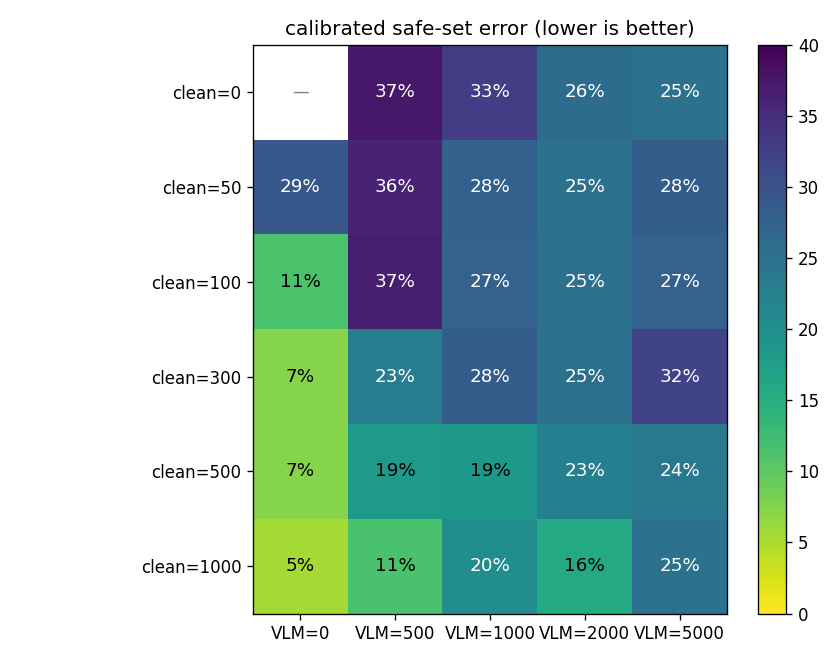

vlm_label_bias.png


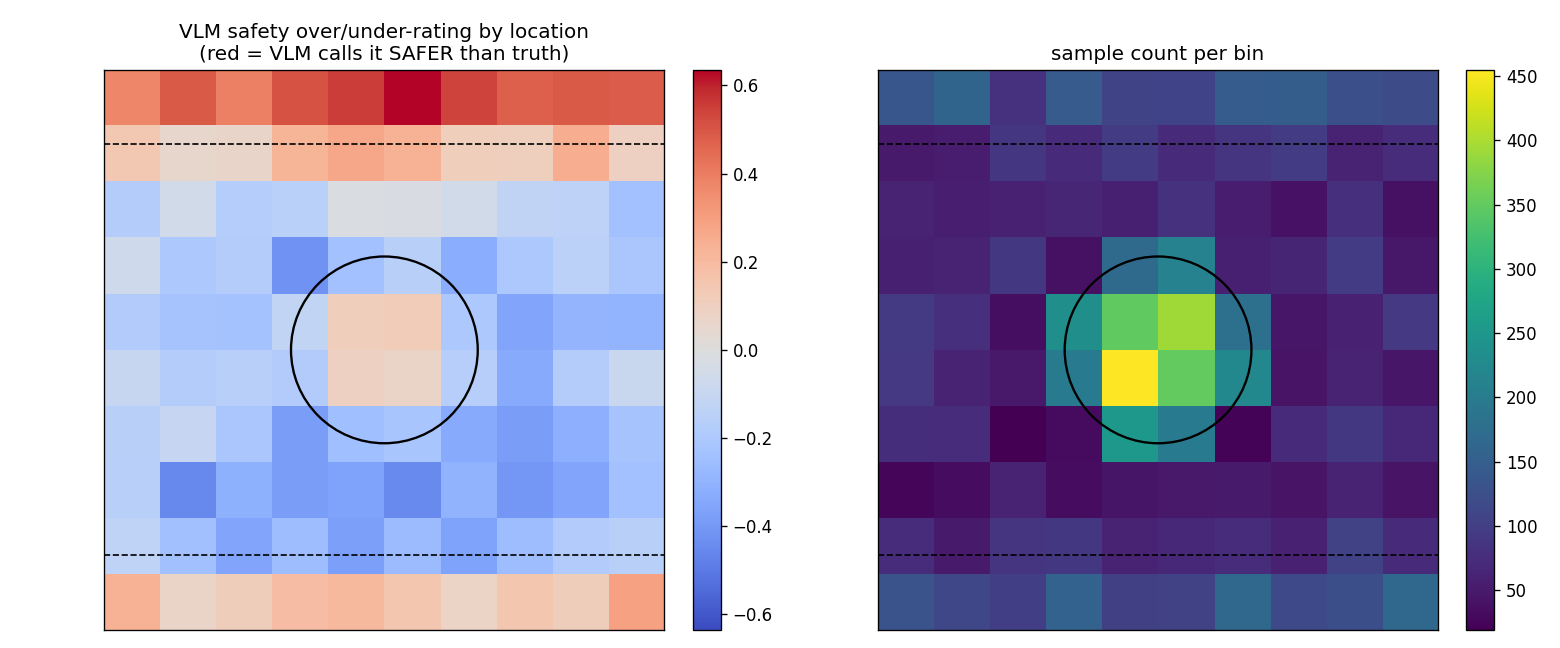

vlm_perception_map.png


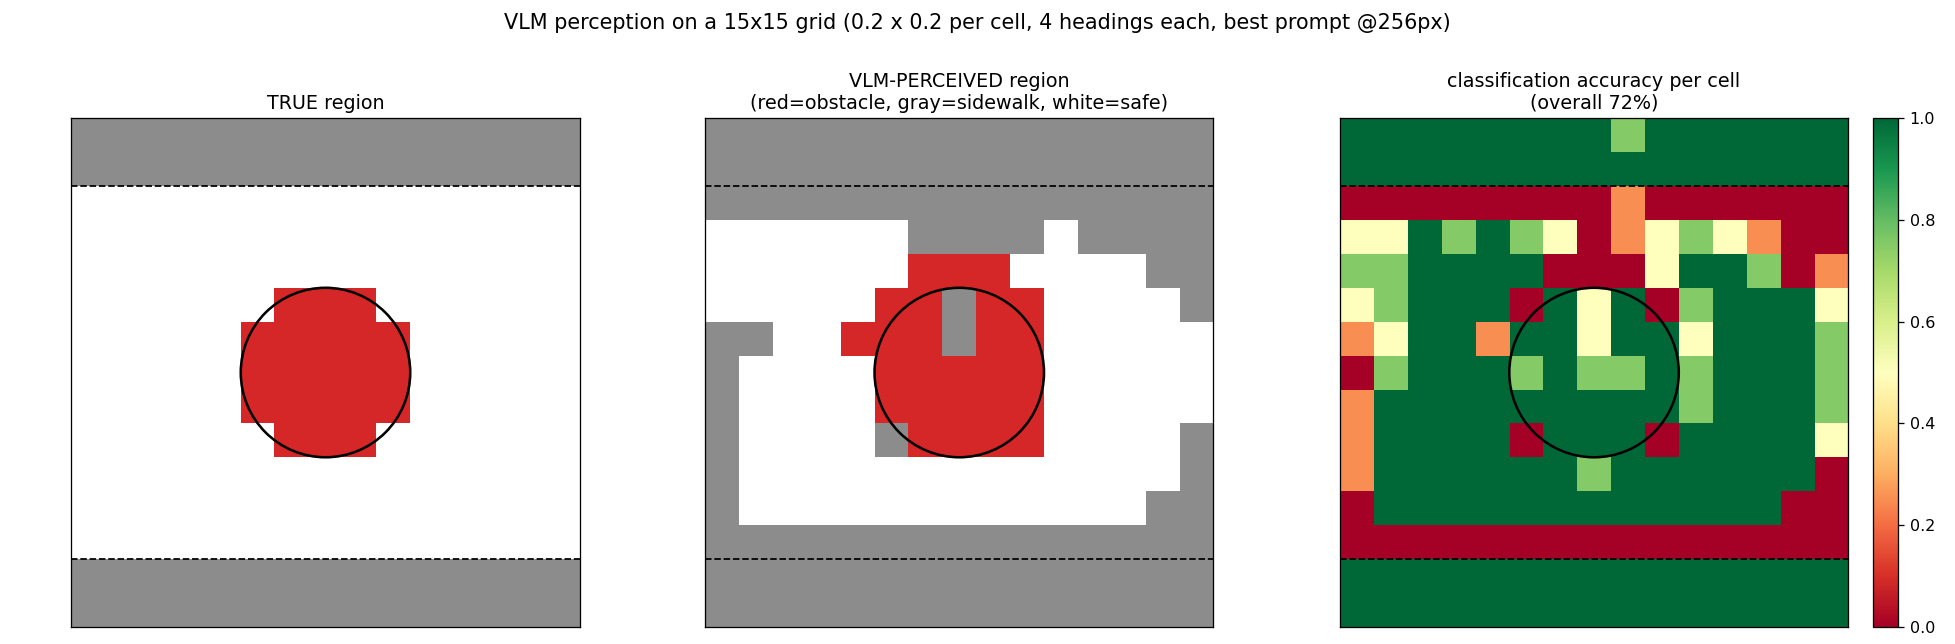

In [10]:
from IPython.display import Image as IPImage, display
for f in ["vlm_margin_safeseterr_stepwise.png","vlm_label_bias.png","vlm_perception_map.png"]:
    p=f"visualizations/{f}"
    if os.path.exists(p): print(f); display(IPImage(filename=p,width=820))

## 8. Findings

1. **Labeling method dominates prompt wording.** Direct pairwise **0.697** → stepwise with worked
   demos **0.746** on 5000 pairs (0.807 on a 300-pair slice). Zero-shot with the *same* rules is
   **0.587** — the worked demos, not the structure, carry the gain.
2. **The VLM is far better at single-image perception than two-image comparison.** Classifying one
   state reaches **0.85–0.89**; asking it to compare two caps around **0.75–0.80**. A decomposed
   variant (classify each state, then rank) hits **0.868**, but it moves the comparison out of the
   VLM, so it is not a like-for-like labeler.
3. **The margin's zero must be calibrated.** BT leaves the offset free; it drifts as labels
   accumulate (98% of the map above zero at 5000 labels). ~50 sign-only anchors recover the oracle
   zero and cut safe-set error **35% → 25%**. This applies to *any* BT margin feeding the filter.
4. **VLM labels genuinely improve with scale — once calibrated.** Safe-set error falls
   37% → 25% from 500 → 5000 labels, and margin accuracy rises 0.76 → 0.80.
5. **Clean labels still dominate, and more so on the safety metric.** 1000 clean labels give
   **0.986 / 5%** vs the best VLM-only **0.80 / 25%**, and mixing VLM into clean degrades it at every
   budget. On this task the VLM is not yet a substitute for clean supervision.

**Caveats.** set_a only; safe-vs-sidewalk confusion near boundaries is a localization limit that
prompting shifts but does not fix; the ranking is supplied to the VLM in language (it can also derive
it itself — verified separately).